In [1]:
import numpy as np #for numercial calculations
import matplotlib.pyplot as plt #for visualising the results
from scipy.integrate import solve_ivp #for solving the differential equations

In [2]:
m1 = 1.0 #mass of first pendulum in kg
m2 = 1.0 #mass of second pendulum in kg

L1 = 1.0 #length of first rod in m
L2 = 1.0 #length of second rod in m

g = 9.81 #gravitational acceleration in m/s^2

In [3]:
#defining equations of motion
def equations_of_motion(t, y):
  theta1, theta2, omega1, omega2 = y #the four variable from the state vector

  delta = theta1 - theta2 #the difference between the two angles

  denominator = m1 + m2 - m2 * np.cos(delta)**2

  alpha1 = (
      -m2 * L1 * omega1**2 * np.sin(delta) * np.cos(delta)
      -m2 * L2 * omega2**2 * np.sin(delta)
      -(m1 + m2) * g * np.sin(theta1)
      +m2 * g * np.sin(theta2) * np.cos(delta)
  ) / (L1 * denominator)

  alpha2 = (
      (m1 + m2) * L1 * omega1**2 * np.sin(delta)
      +m2 * L2 * omega2**2 * np.sin(delta) * np.cos(delta)
      +(m1 + m2) * g * np.sin(theta1) * np.cos(delta)
      -(m1 + m2) * g * np.sin(theta2)
  ) / (L2 * denominator)

  return [omega1, omega2, alpha1, alpha2]

In [4]:
#setting initial conditions
theta1_0 = np.pi / 2 #90 degrees in radians
theta2_0 = np.pi / 2

omega1_0 = 0.0 #angular velocity
omega2_0 = 0.0

y0 = [theta1_0, theta2_0, omega1_0, omega2_0]

In [5]:
#simulation time

t_start = 0
t_end = 20

#simulation running from 0 to 20 seconds

t_eval = np.linspace(t_start, t_end, 5000)

#nplinspace gives us 5000 evenly spaced timepoints

In [6]:
#solving the equations using scipy

solution = solve_ivp(
    equations_of_motion,
    (t_start, t_end),
    y0,
    t_eval=t_eval
)

In [7]:
#extracting results
theta1 = solution.y[0]
theta2 = solution.y[1]
omega1 = solution.y[2]
omega2 = solution.y[3]

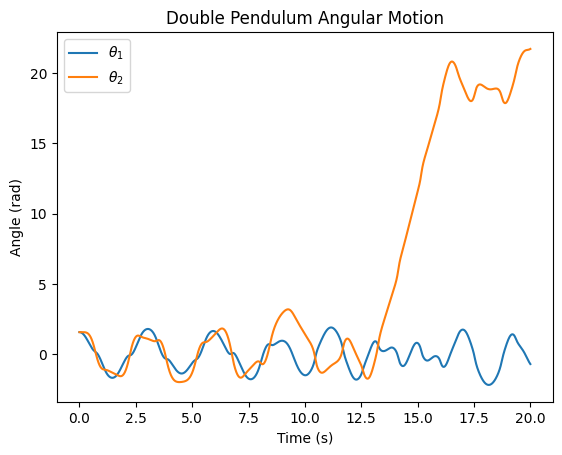

In [8]:
#plotting the graph
plt.plot(solution.t, theta1, label=r'$\theta_1$')
plt.plot(solution.t, theta2, label=r'$\theta_2$')

plt.xlabel('Time (s)')
plt.ylabel('Angle (rad)')
plt.title('Double Pendulum Angular Motion')
plt.legend()
plt.show()

In [9]:
#calculating x and y coordinates of both masses

x1 = L1 * np.sin(theta1)
y1 = -L1 * np.cos(theta1)

x2 = L1 * np.sin(theta1) + L2 * np.sin(theta2)
y2 = -L1 * np.cos(theta1) - L2 * np.cos(theta2)

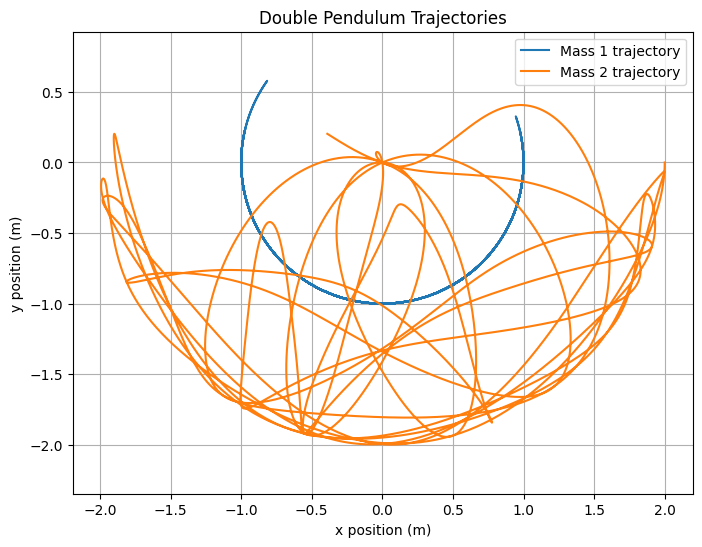

In [11]:
#plotting the trajectories of both masses

plt.figure(figsize=(8, 6))

plt.plot(x1, y1, label='Mass 1 trajectory')
plt.plot(x2, y2, label='Mass 2 trajectory')

plt.xlabel('x position (m)')
plt.ylabel('y position (m)')
plt.title('Double Pendulum Trajectories')
plt.axis('equal')
plt.legend()
plt.grid()
plt.show()

In [13]:
#calculating energy

#kinetic energy
KE1 = 0.5 * m1 * L1**2 * omega1**2

KE2 = 0.5 * m2 * (
    L1**2 * omega1**2
    + L2**2 * omega2**2
    + 2 * L1 * L2 * omega1 * omega2 * np.cos(theta1 - theta2)
)

KE = KE1 + KE2

#potential Energy
PE = (
    -(m1 + m2) * g * L1 * np.cos(theta1)
    - m2 * g * L2 * np.cos(theta2)
)

#total energy
total_energy = KE + PE

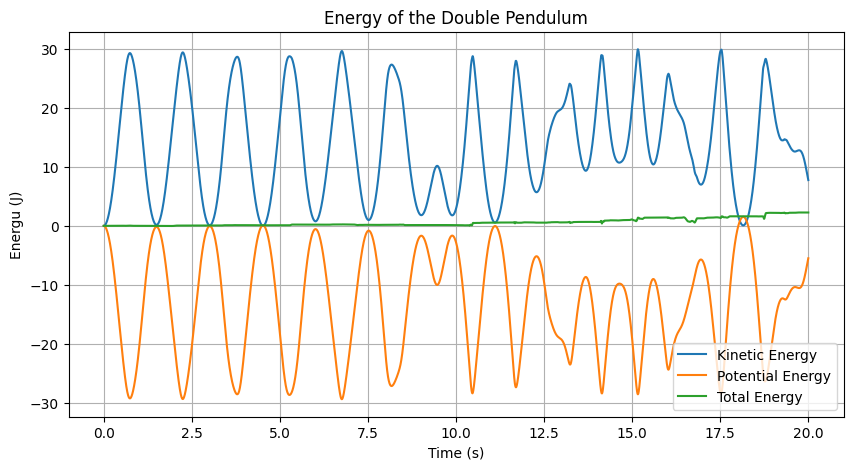

In [14]:
#plotting the energy

#total energy should remain approximately constant - small variations can occur because the solution is numerical not exact

plt.figure(figsize=(10, 5))

plt.plot(solution.t, KE, label='Kinetic Energy')
plt.plot(solution.t, PE, label='Potential Energy')
plt.plot(solution.t, total_energy, label='Total Energy')

plt.xlabel('Time (s)')
plt.ylabel('Energu (J)')
plt.title('Energy of the Double Pendulum')
plt.legend()
plt.grid()
plt.show()

In [17]:
#checking the numerical energy error

initial_energy = total_energy[0]

relative_energy_error = (
    np.abs(total_energy - initial_energy)
    / np.abs(initial_energy)
)

print(f"Maximum relative energy error: {np.max(relative_energy_error):.6e}")

Maximum relative energy error: 1.257513e+15


In [19]:
#exporting the simulation data

import pandas as pd

data = pd.DataFrame({
    'time': solution.t,
    'theta1': theta1,
    'theta2': theta2,
    'omega1': omega1,
    'omega2': omega2,
    'x1': x1,
    'y1': y1,
    'x2': x2,
    'y2': y2,
    'kinetic_energy': KE,
    'potential_energy': PE,
    'total_energy': total_energy
})

data.head()

,time,theta1,theta2,omega1,omega2,x1,y1,x2,y2,kinetic_energy,potential_energy,total_energy
0,0.000000,1.570796,1.570796,0.000000,0.000000e+00,1.000000,-6.123234e-17,2.000000,-1.224647e-16,0.000000,-1.802068e-15,-1.802068e-15
1,0.004001,1.570718,1.570796,-0.039248,-1.544554e-09,1.000000,-7.851140e-05,2.000000,-7.851141e-05,0.001540,-1.540394e-03,8.273646e-12
2,0.008002,1.570482,1.570796,-0.078496,-1.023978e-08,1.000000,-3.140456e-04,2.000000,-3.140456e-04,0.006162,-6.161575e-03,1.604746e-12
3,0.012002,1.570090,1.570796,-0.117744,-6.921251e-08,1.000000,-7.066025e-04,2.000000,-7.066026e-04,0.013864,-1.386354e-02,8.024395e-12
4,0.016003,1.569540,1.570796,-0.156991,-2.972869e-07,0.999999,-1.256182e-03,1.999999,-1.256182e-03,0.024646,-2.464629e-02,4.366795e-12


In [21]:
data.to_csv('double_pendulum_simulation.csv', index=False)

In [22]:
from google.colab import files

files.download('double_pendulum_simulation.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
#basic dataset information
print("Number of data points:", len(data))
print("Simulation duration:", data['time'].iloc[-1], "seconds")

#summary statistics
print("\nSummary statistics:")
print(data[['theta1', 'theta2', 'omega1', 'omega2',
            'kinetic_energy', 'potential_energy',
            'total_energy']].describe())

Number of data points: 5000
Simulation duration: 20.0 seconds

Summary statistics:
            theta1       theta2       omega1       omega2  kinetic_energy  \
count  5000.000000  5000.000000  5000.000000  5000.000000     5000.000000   
mean     -0.025781     5.241903    -0.113818     1.007983       13.943944   
std       1.058285     8.057452     2.970395     3.884903        8.827145   
min      -2.187335    -1.987600    -7.678189    -8.827859        0.000000   
25%      -0.845809    -0.655418    -2.531925    -1.510876        6.449804   
50%       0.010957     1.150771    -0.226197     0.615106       13.168020   
75%       0.791180    11.584464     2.258765     4.538568       21.424224   
max       1.903412    21.732422     7.407795    10.713984       29.952776   

       potential_energy  total_energy  
count       5000.000000   5000.000000  
mean         -13.343710      0.600234  
std            8.786426      0.644698  
min          -29.399211     -0.022285  
25%          -20.802240

In [24]:
#specific measurements

#calculating the maximum distance from the pivot to use as an example of extracting features from simulation

max_omega1 = np.max(np.abs(data['omega1']))
max_omega2 = np.max(np.abs(data['omega2']))

max_displacement_1 = np.max(np.sqrt(data['x1']**2 + data['y1']**2))
max_displacement_2 = np.max(np.sqrt(data['x2']**2 + data['y2']**2))

print(f"Maximum angular velocity of mass 1: {max_omega1:.3f} rad/s")
print(f"Maximum angular velocity of mass 2: {max_omega2:.3f} rad/s")

print(f"Maximum distance of mass 1 from pivot: {max_displacement_1:.3f} m")
print(f"Maximum distance of mass 2 from pivot: {max_displacement_2:.3f} m")

Maximum angular velocity of mass 1: 7.678 rad/s
Maximum angular velocity of mass 2: 10.714 rad/s
Maximum distance of mass 1 from pivot: 1.000 m
Maximum distance of mass 2 from pivot: 2.000 m


In [25]:
#exploring sensitivity to initial conditions

#original initial conditions
y0_a = [
    np.pi / 2,
    np.pi / 2,
    0.0,
    0.0
]

#slightly different inital conditions
y0_b = [
    np.deg2rad(90.01),
    np.pi / 2,
    0.0,
    0.0
]

#run both simulations
solution_a = solve_ivp(
    equations_of_motion,
    (t_start, t_end),
    y0_a,
    t_eval=t_eval
)

solution_b = solve_ivp(
    equations_of_motion,
    (t_start, t_end),
    y0_b,
    t_eval=t_eval
)

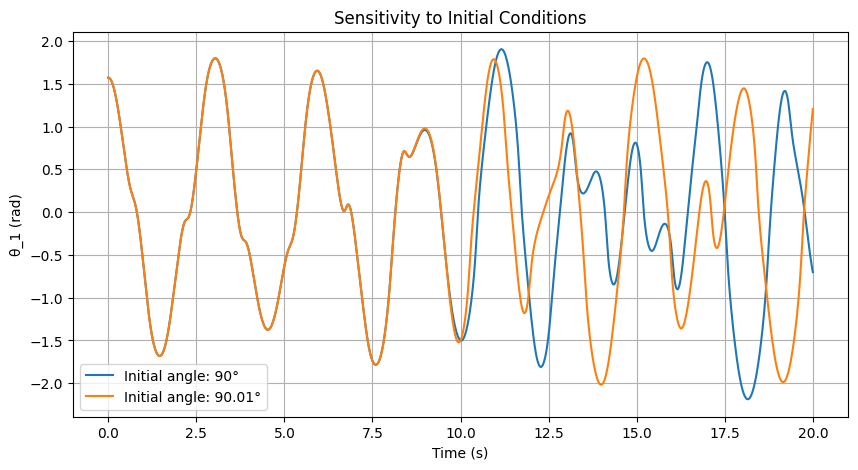

In [27]:
#comparing the first angles on a plot

theta1_a = solution_a.y[0]
theta1_b = solution_b.y[0]

plt.figure(figsize=(10, 5))

plt.plot(solution_a.t, theta1_a, label='Initial angle: 90°')
plt.plot(solution_b.t, theta1_b, label='Initial angle: 90.01°')

plt.xlabel('Time (s)')
plt.ylabel('θ_1 (rad)')
plt.title('Sensitivity to Initial Conditions')
plt.legend()
plt.grid()
plt.show()

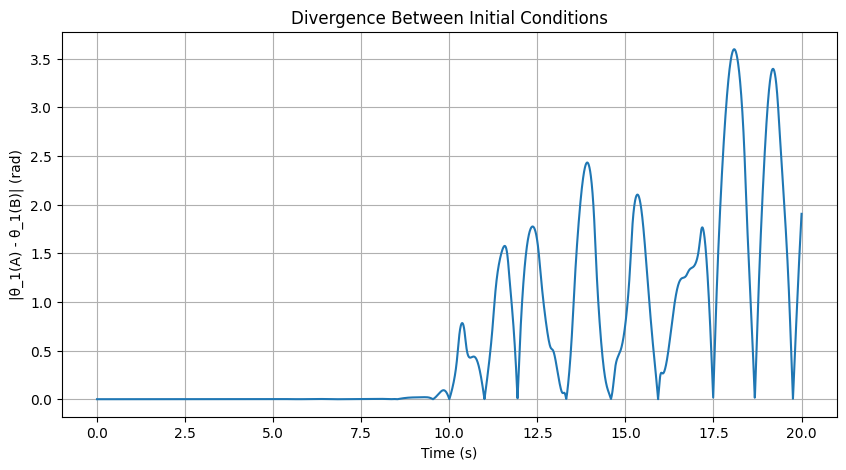

In [28]:
#plotting the divergence

difference = np.abs(theta1_a - theta1_b)

plt.figure(figsize=(10, 5))

plt.plot(solution_a.t, difference)

plt.xlabel('Time (s)')
plt.ylabel('|θ_1(A) - θ_1(B)| (rad)')
plt.title('Divergence Between Initial Conditions')
plt.grid()
plt.show()